In [1]:
import os, sys, json, pickle, itertools, numpy as np, pandas as pd, scipy.sparse as sp
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_auc_score
import networkx as nx



import sys
sys.path.append('..')


In [2]:
data_path = "data"

In [9]:
import anndata

adata = anndata.read_h5ad(os.path.join(data_path, "SEAAD_MTG_MERFISH_all-nuclei.2023-05-08.h5ad"))
adata

AnnData object with n_obs × n_vars = 1321191 × 180
    obs: 'Donor ID', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in months', 'APOE4 Status', 'Primary Study Name', 'Secondary Study Name', 

In [21]:
adata = anndata.read_h5ad(os.path.join(data_path, "microglia_traj_0234_subset_fewer_pt.h5ad"))
adata

AnnData object with n_obs × n_vars = 3526 × 36601
    obs: 'sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in month

In [26]:
adata.obs['Brain Region'].value_counts()

Brain Region
Human MTG               3391
Human MTG All Layers     135
Name: count, dtype: int64

In [11]:
traj_data = np.load(f"{data_path}/microglia_subtraj_gene_space_for_ritini.npz", allow_pickle=True)
preds = np.load(f"{data_path}/32-granger-preds.npy")
genes = np.load(f"{data_path}/32-granger-genes.npy", allow_pickle=True)

In [13]:
traj_data['trajectories'].shape

(100, 100, 36601)

In [15]:
adata.var_names

Index(['RORB', 'LAMP5', 'MEIS2', 'KIRREL3', 'DCC', 'TNR', 'PAX6', 'GRIP1',
       'GRIN2A', 'CHODL',
       ...
       'Blank-35', 'Blank-37', 'Blank-14', 'Blank-23', 'Blank-39', 'Blank-38',
       'Blank-6', 'Blank-13', 'Blank-4', 'Blank-8'],
      dtype='object', length=180)

In [18]:
adata.obs['Subclass'].value_counts()

Subclass
Oligodendrocyte    402827
Microglia-PVM      158518
Astrocyte          148691
L2/3 IT            102818
L4 IT               67445
L5 IT               61527
Endothelial         58017
OPC                 53356
VLMC                47338
L6 IT               45352
L6 IT Car3          26818
L6b                 22759
Pvalb               22189
Vip                 19014
Sst                 16921
L6 CT               16448
Lamp5               12982
Lamp5 Lhx6          12116
L5/6 NP              8927
Sncg                 4154
L5 ET                3974
Sst Chodl            3567
Chandelier           3254
Pax6                 2179
Name: count, dtype: int64

In [16]:
adata.obsm['spatial']

array([[2938.45034831, 7844.09875894],
       [4329.37358886, 4700.93144971],
       [3201.90701698, 6726.63980042],
       ...,
       [5790.84502695, 5741.07335229],
       [2762.05317698, 2764.82526415],
       [5202.7512921 , 3270.09677968]], shape=(1321191, 2))

In [27]:
data = {}

In [28]:
data['gene_expression'] = traj_data['trajectories']

In [91]:
traj_data['trajectories'].shape

(100, 100, 36601)

NameError: name 'traj_data' is not defined

In [6]:

# Extract data from the loaded simulation results
# Based on the saving function structure:
# - 'genes' is a 3D array (time_points x cells x genes)
# - 'positions' is a 3D array (time_points x cells x 2)
# - 'metadata' contains time_points, cell_ids, gene_names, cell_types, and prior_grns

# Extract gene expression data (time_points x cells x genes)
data['gene_expression'] = traj_data['trajectories']
# Extract cell positions (time_points x cells x 2)
# data['cell_positions'] = torch.tensor(sim_data['positions'],dtype=torch.float32)


# Extract gene names
data['genes'] = traj_data['genes']

# Extract cell type assignments
cell_ids = metadata['cell_ids']

# Map each cell ID to its corresponding integer label
assignments = traj_data['annotations']

data['cell_type_assignments'] = torch.tensor(assignments, dtype=torch.long)

# Extract prior GRNs
cell_specific_prior_grns =  [metadata['prior_grns'][cell_type] for cell_type in label_to_int.keys()]
data['prior_grns'] = cell_specific_prior_grns

data['receptor_gene_pairs'] = metadata['receptor_gene_pairs']
data['ligand_receptor_pairs'] = metadata['ligand_receptor_pairs']

    # Calculate dimensions
data['n_time_points'] = data['gene_expression'].shape[0]
data['n_cells'] = data['gene_expression'].shape[1]
data['n_genes'] = data['gene_expression'].shape[2]


NameError: name 'traj_data' is not defined

In [11]:
# import scipy.cluster.hierarchy as sch
# from matplotlib.colors import LinearSegmentedColormap
data = preds[0,...]
# # Compute the distance matrix
# row_dist = sch.distance.pdist(data)
# col_dist = sch.distance.pdist(data.T)

# # Perform hierarchical clustering
# row_clusters = sch.linkage(row_dist, method='ward')
# col_clusters = sch.linkage(col_dist, method='ward')

# # Create a dendrogram and reorder the data according to the clusters
# row_order = sch.leaves_list(row_clusters)
# # col_order = sch.leaves_list(col_clusters)

# reordered_data = data[row_order, :][:, row_order]
# reordered_genes = genes[row_order]

# colors = [(1, 1, 1), (1, 0, 0)]  # White to Red
# n_bins = 100  # Number of bins for interpolation

# cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=n_bins)

# plt.figure(figsize=(30, 28))  
# plt.imshow(reordered_data, cmap=cmap, interpolation='nearest')
# plt.xticks(ticks=np.arange(len(genes)), labels=reordered_genes, rotation=90)
# plt.yticks(ticks=np.arange(len(genes)), labels=reordered_genes)

# cbar = plt.colorbar(label='Values', fraction=0.046, pad=0.04, shrink=0.8)
# cbar.ax.tick_params(labelsize=20)
# cbar.set_label('Values', fontsize=20)
# plt.title('GRN inferred from trajectories with Granger Causality', fontsize=20)
# plt.show()

In [12]:
# top=50
# top_data = reordered_data[:top, :][:, :top]
# top_genes = reordered_genes[:top]

# colors = [(1, 1, 1), (1, 0, 0)]  # White to Red
# n_bins = 100  # Number of bins for interpolation

# cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=n_bins)

# plt.figure(figsize=(20, 18))  
# plt.imshow(top_data, cmap=cmap, interpolation='nearest')
# plt.xticks(ticks=np.arange(len(top_genes)), labels=top_genes, rotation=90)
# plt.yticks(ticks=np.arange(len(top_genes)), labels=top_genes)

# cbar = plt.colorbar(label='Values', fraction=0.046, pad=0.04, shrink=0.8)
# cbar.ax.tick_params(labelsize=20)
# cbar.set_label('Values', fontsize=20)
# plt.title('GRN inferred from trajectories with Granger Causality', fontsize=20)
# plt.show()

In [9]:
top_data = data
top_genes = genes

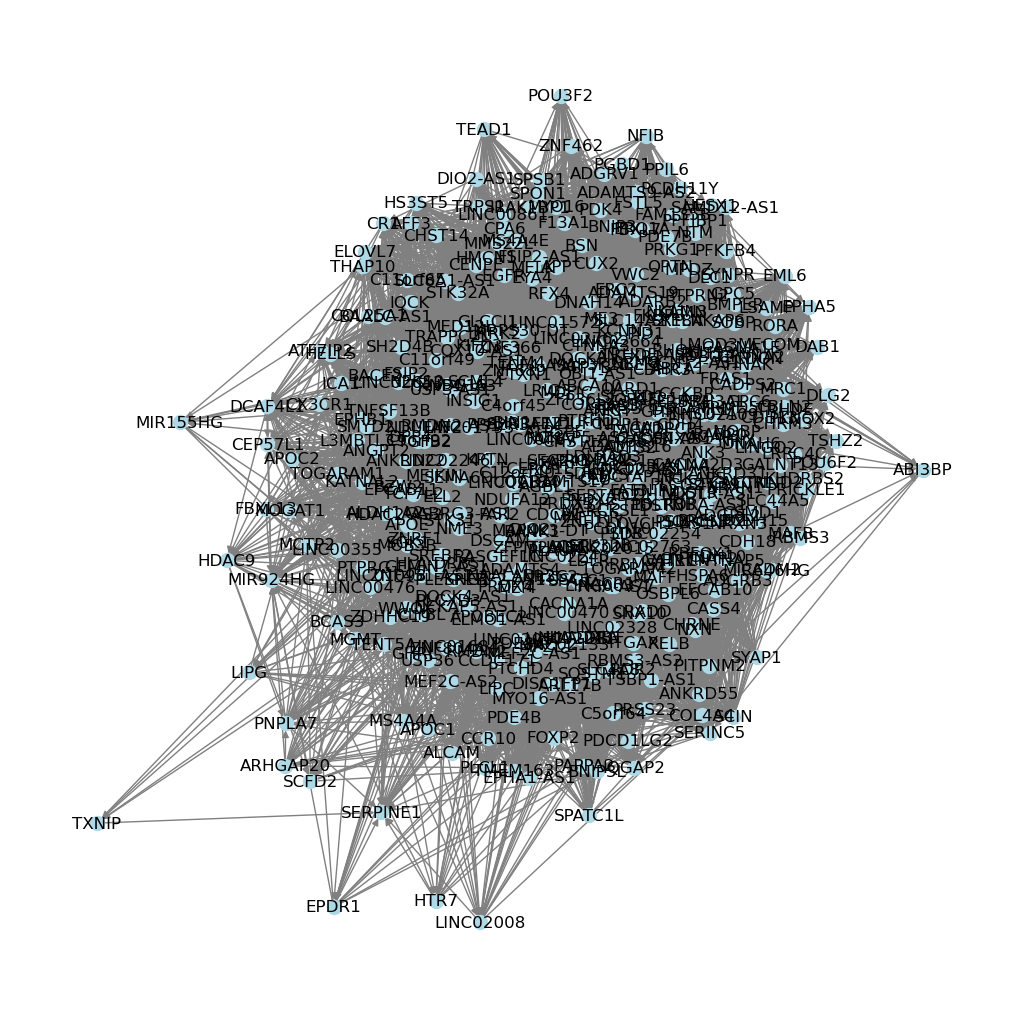

In [8]:
import networkx as nx
# Create a directed graph from the adjacency matrix
G = nx.DiGraph()

# Add nodes with labels
for i, label in enumerate(top_genes):
    G.add_node(i, label=label)

# Add edges based on the adjacency matrix
for i in range(top_data.shape[0]):
    for j in range(top_data.shape[1]):
        if top_data[i, j] >= 5.:
            G.add_edge(i, j)

# Extract node labels
labels = nx.get_node_attributes(G, 'label')

# Draw the graph
pos = nx.spring_layout(G.to_undirected())  # Positioning of nodes
plt.figure(figsize=(10,10))
nx.draw(G, pos, with_labels=True, labels=labels, node_size=100, node_color='lightblue', edge_color='gray', arrows=True)
# nx.draw_networkx_edge_labels(G, pos, edge_labels={(i, j): top_data[i, j] for i, j in G.edges()}, font_color='red')

plt.show()

In [20]:
traj_data['genes']

array(['MIR1302-2HG', 'FAM138A', 'OR4F5', ..., 'AC007325.1', 'AC007325.4',
       'AC007325.2'], shape=(36601,), dtype=object)

In [16]:
traj_data['trajectories']

array([[[ 1.08834531e-04,  4.04864323e-07, -2.54139712e-04, ...,
          1.90444756e-04,  2.39501358e-03, -2.34803490e-04],
        [-6.37658013e-05, -1.43148407e-06, -4.66721773e-04, ...,
          5.07552933e-04,  9.12973192e-04,  6.67019340e-04],
        [-2.33426574e-04,  8.42533552e-07,  7.23552075e-04, ...,
          1.56055135e-03,  1.56742055e-03, -1.63579985e-04],
        ...,
        [-1.97696732e-04,  8.31563398e-07, -2.75233237e-04, ...,
          1.09854504e-03,  6.36109523e-03, -1.89908184e-04],
        [ 2.14536849e-04,  1.32543221e-07, -3.77186749e-04, ...,
          7.62429787e-04,  7.92822335e-04, -2.05876029e-04],
        [ 1.54280679e-05,  7.36945310e-07, -2.42714290e-04, ...,
         -9.62900231e-06,  2.99045234e-03, -8.86158814e-05]],

       [[ 6.67863205e-05,  5.82223493e-07, -1.69286985e-04, ...,
         -1.37580559e-04,  3.81271075e-03, -4.07396292e-04],
        [-7.68842219e-05, -1.71531838e-06, -3.83965031e-04, ...,
          6.07599737e-04,  5.05438074e

In [12]:
edges = list(G.edges())
u, v = np.array(edges).T
u = torch.IntTensor(u)
v = torch.IntTensor(v)


g = dgl.graph((u, v))
num_edges = g.number_of_edges()

# Assign a default edge weight of 1.0 to all edges
# g.edata['weight'] = torch.ones(num_edges)

g.ndata['feat'] = torch.Tensor(np.ones((len(g.nodes()), 1)))

# g = dgl.from_networkx(G)
# g.ndata['feat'] = torch.Tensor(np.ones((len(g.nodes()), 1)))


ref_g = g.to_networkx()
ref_pos = nx.spring_layout(ref_g.to_undirected(), seed=seed)

for idx, node in enumerate(ref_g.nodes()):
    ref_g.nodes[idx]['color'] = plt.get_cmap('viridis', len(top_genes))(idx)
    ref_g.nodes[idx]['label'] = top_genes[idx]

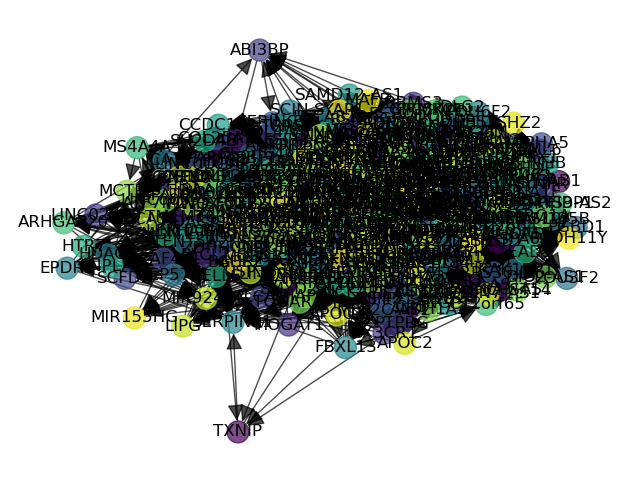

In [13]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1,1,1)

nx.draw_networkx_labels(
    ref_g, pos=ref_pos, ax=ax,
    labels=nx.get_node_attributes(ref_g,'label'),
    font_size=12, font_color='black'
)

nx.draw(
    ref_g, pos=ref_pos, ax=ax,
    with_labels=False,
    node_color=list(nx.get_node_attributes(ref_g, 'color').values()),
    edge_cmap=plt.cm.magma,
    node_size=250, arrowsize=25, alpha=0.7
)

In [14]:
# Mapping for edge ids
edge_ids = np.arange(g.number_of_edges())

# Shuffle
edge_ids = np.random.permutation(edge_ids)

test_size_percent = 30
test_size_fraction = test_size_percent / 100

edge_test_size = int(len(edge_ids) * test_size_fraction)
edge_train_size = g.number_of_edges() - edge_test_size

In [15]:
edge_test_pos_u = u[edge_ids[:edge_test_size]]
edge_test_pos_v = v[edge_ids[:edge_test_size]]

edge_train_pos_u = u[edge_ids[edge_test_size:]]
edge_train_pos_v = v[edge_ids[edge_test_size:]]

In [16]:
adjaceny_matrix = nx.adjacency_matrix(G)
adjaceny_matrix_negative = 1 - adjaceny_matrix.todense() - np.eye(g.number_of_nodes())

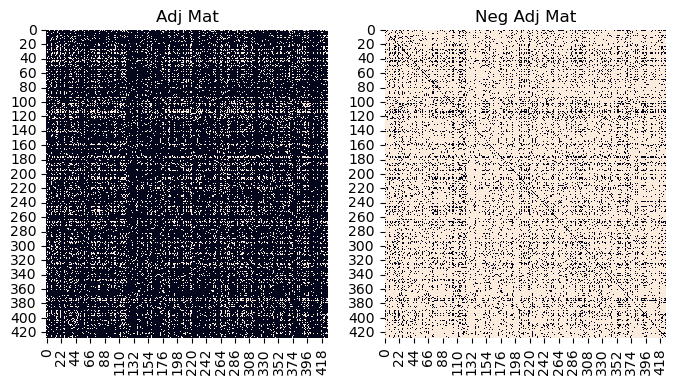

In [17]:
fig = plt.figure(figsize=(8, 4))
axes = fig.subplots(1, 2)

sns.heatmap(adjaceny_matrix.todense(), label='Adj Mat', ax=axes[0], cbar=False);
axes[0].set_title('Adj Mat');
sns.heatmap(adjaceny_matrix_negative, label='Neg Adj Mat', ax=axes[1], cbar=False);
axes[1].set_title('Neg Adj Mat');

In [18]:
from gode.odeblock import ODEBlock
from gode.gde import GDEFunc
from gode.dgl import DGLSAGEConv, DGLGATConv, MeanAttentionLayer

from gode.data import (
    make_mean_data_ti, make_train_test_dataframe, 
    get_data_ti, representative_cell_types_at_t,
    sample_group_index, sample_aggregate_group_at_t
)

def get_data_ti(
    df:pd.DataFrame, 
    t, 
    size:int,
    features,
    replace:bool=False,
    time_key:str='pseudotime',
    groupby:str='cell_types',
    device:torch.device=None
):
    if device is None:
        device = get_device()
        
    return torch.Tensor(
        sample_aggregate_group_at_t(
            df, t, time_key=time_key, 
            size=size, replace=replace,
            groupby=groupby, features=features
        ).values
    ).T#.to(device).T


In [19]:
def get_n_cells_of_type_k_at_time_t(df, n, k, t, genes=top_genes):
    n_genes = len(genes)
    groups = df.groupby(['cell_types', 'pseudotime'])
    if (k, t) not in groups.groups:
        values = np.array([[0 for cell in range(n)] for gene in range(n_genes)])
    else:
        values = groups.get_group((k, t))\
            .filter(genes).sample(n, replace=True)\
            .values.T
        
    # e.g. shape = (100 genes, 10 cells)
    genes_x_cells = values
    return genes_x_cells

In [20]:
traj_data['trajectories'].shape

(100, 100, 36601)

In [21]:
gene_subset_indices = np.where(np.isin(traj_data['genes'], top_genes))[0]
np.random.seed(32)
cell_subset_indices = np.random.choice(traj_data['trajectories'].shape[1], 50, replace=False)

trajs = traj_data['trajectories']
trajs = trajs[::3]
trajs = trajs[:, cell_subset_indices]
trajs = trajs[:, :, gene_subset_indices]

In [22]:
trajs.shape

(34, 50, 428)

In [23]:
pseudotimes = np.linspace(0, 1, trajs.shape[0])

In [24]:
traj_f = trajs.reshape(-1, trajs.shape[2])
annot_repeated = np.repeat(traj_data['annotations'][cell_subset_indices], trajs.shape[0])
pt_repeated = np.tile(pseudotimes, trajs.shape[1])
df = pd.DataFrame(traj_f, columns=top_genes, index=[f'cell_{i}' for i in range(traj_f.shape[0])])
df['pseudotime'] = pt_repeated
df['cell_types'] = [f'cell_type_{a}' for a in annot_repeated]

In [25]:
def get_n_cells_of_all_types_at_time_t(df, n, t, types=np.unique(df['cell_types']), genes=top_genes):
    return np.hstack(tuple([
        get_n_cells_of_type_k_at_time_t(df, n, k, t, genes=genes)
        for k in types
    ]))


In [26]:
# import pca
import phate
phate_operator = phate.PHATE(t=100)
t_phate = phate_operator.fit_transform(traj_f)

Calculating PHATE...
  Running PHATE on 1700 observations and 428 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.14 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.24 seconds.
    Calculating affinities...
  Calculated graph and diffusion operator in 0.40 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.93 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 18.45 seconds.
Calculated PHATE in 19.81 seconds.


<Axes: >

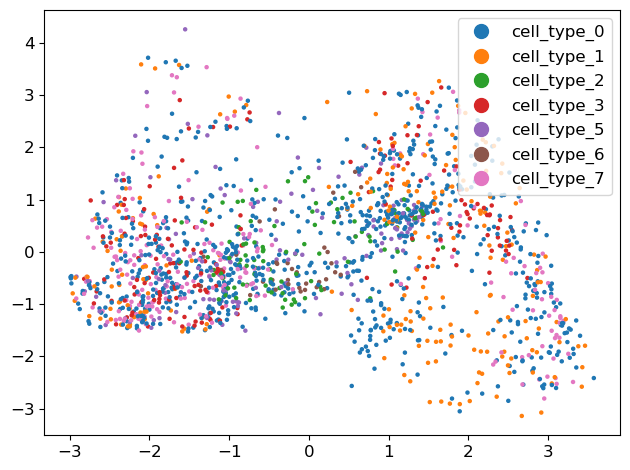

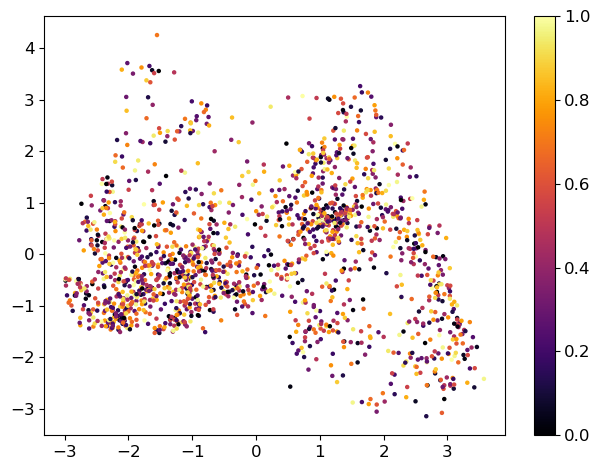

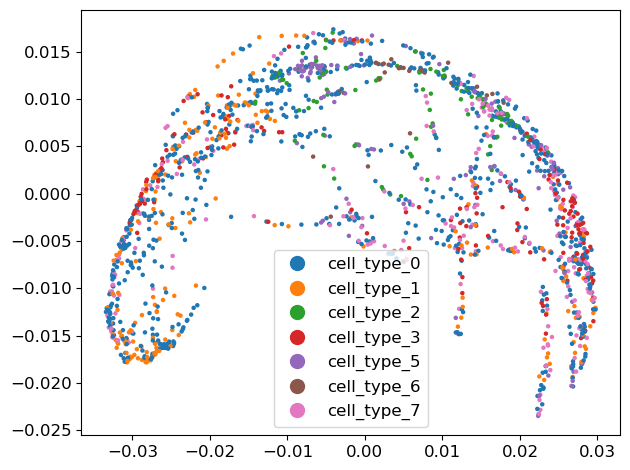

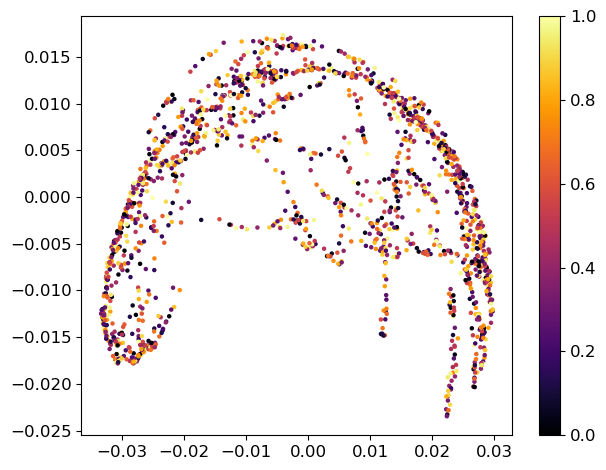

In [27]:
import scprep
scprep.plot.scatter2d(phate_operator.graph.data_nu, df['cell_types'])
scprep.plot.scatter2d(phate_operator.graph.data_nu, df['pseudotime'])
scprep.plot.scatter2d(t_phate, df['cell_types'])
scprep.plot.scatter2d(t_phate, df['pseudotime'])

In [28]:
df_train, df_test = make_train_test_dataframe(df)

In [29]:
neg_u, neg_v = np.where(adjaceny_matrix_negative != 0)
neg_edge_ids = np.random.choice(len(neg_u), g.number_of_edges())

edge_test_neg_u = neg_u[neg_edge_ids[:edge_test_size]]
edge_test_neg_v = neg_v[neg_edge_ids[:edge_test_size]]
edge_train_neg_u = neg_u[neg_edge_ids[edge_test_size:]]
edge_train_neg_v = neg_v[neg_edge_ids[edge_test_size:]]

In [30]:
train_g = dgl.remove_edges(g, edge_ids[:edge_test_size])

train_pos_g = dgl.graph(
    (edge_train_pos_u, edge_train_pos_v), 
    num_nodes=g.number_of_nodes()
)

train_neg_g = dgl.graph(
    (edge_train_neg_u, edge_train_neg_v), 
    num_nodes=g.number_of_nodes()
)

test_pos_g = dgl.graph(
    (edge_test_pos_u, edge_test_pos_v), 
    num_nodes=g.number_of_nodes()
)

test_neg_g = dgl.graph(
    (edge_test_neg_u, edge_test_neg_v), 
    num_nodes=g.number_of_nodes()
)

In [31]:
class DGLGATConv(conv.GATConv):
    def __init__(self, graph, in_feats, out_feats, num_heads, feat_drop=0.0, attn_drop=0.0, negative_slope=0.2, residual=False, activation=None, allow_zero_in_degree=False, bias=True):
        super(DGLGATConv, self).__init__(in_feats, out_feats, num_heads, feat_drop, attn_drop, negative_slope, residual, activation, allow_zero_in_degree, bias)
        self.graph = graph

    def forward(self, feat, get_attention=False):
        return super().forward(self.graph, feat, edge_weight=None, get_attention=get_attention) # updated to address a possible api change in the latest version.

In [32]:
n_cells_at_t = df['pseudotime'].value_counts()[0]

time_bins = np.sort(df.pseudotime.unique())
cell_types = np.sort(df.cell_types.unique())

t0, *_, tn = time_bins
time_tensor = torch.Tensor(time_bins)#.to(device)

in_feats = cell_types.size * n_cells_at_t
out_feats = cell_types.size * n_cells_at_t

In [33]:
nodes_names = [top_genes[i] for i in train_g.nodes().numpy()]
node_map_full = {n:i for i, n in enumerate(nodes_names)}
# tfs = 'gene_0 gene_10 gene_20 gene_30'.split()
tfs = top_genes[::5]

In [34]:
gnn = nn.Sequential( 
    DGLGATConv(
        train_g,
        in_feats=in_feats, out_feats=out_feats, 
        num_heads=1, residual=False,
        activation=nn.Tanh(),
        feat_drop=0.0, attn_drop=0.0,
        allow_zero_in_degree=True
    ),
    MeanAttentionLayer(),
)

gdefunc = GDEFunc(gnn)
gde = ODEBlock(func=gdefunc, method='rk4', atol=1e-3, rtol=1e-4, adjoint=False).to(device)
model = gde

In [35]:
def get_edges_from_graph(g):
    u, v = g.edges()
    u = u.numpy().tolist()
    v = v.numpy().tolist()
    edges = np.vstack((u, v)).T
    return edges

def get_missing_edges_from_edges(g):
    nodes = g.nodes().numpy().tolist()
    all_edges = list(itertools.product(nodes, nodes))
    edges = get_edges_from_graph(g).tolist()  
    return list(filter(lambda e: e not in edges, map(list, all_edges)))

In [36]:
import dgl.function as fn

class DotPredictor(nn.Module):
    def forward(self, g, h):
        with g.local_scope():
            g.ndata['h'] = h
            
            # Compute a new edge feature named 'score' by a dot-product between the
            # source node feature 'h' and destination node feature 'h'.
            
            g.apply_edges(fn.u_dot_v('h', 'h', 'score'))
            
            # u_dot_v returns a 1-element vector for each edge so you need to squeeze it.
            return g.edata['score'][:, 0]
        
        
class MLPPredictor(nn.Module):
    def __init__(self, h_feats):
        super().__init__()
        self.W1 = nn.Linear(h_feats * 2, h_feats)
        self.W2 = nn.Linear(h_feats, 1)

    def apply_edges(self, edges):
        """
        Computes a scalar score for each edge of the given graph.

        Parameters
        ----------
        edges :
            Has three members ``src``, ``dst`` and ``data``, each of
            which is a dictionary representing the features of the
            source nodes, the destination nodes, and the edges
            themselves.

        Returns
        -------
        dict
            A dictionary of new edge features.
        """
        h = torch.cat([edges.src['h'], edges.dst['h']], 1)
        return {'score': self.W2(F.relu(self.W1(h))).squeeze(1)}

    def forward(self, g, h):
        with g.local_scope():
            g.ndata['h'] = h
            g.apply_edges(self.apply_edges)
            return g.edata['score']

In [37]:
pred = DotPredictor()

def compute_link_loss(pos_score, neg_score):
    scores = torch.cat([pos_score, neg_score])
    labels = torch.cat([torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])])
    return F.binary_cross_entropy_with_logits(scores, labels)

def compute_auc(pos_score, neg_score):
    scores = torch.cat([pos_score, neg_score]).numpy()
    labels = torch.cat(
        [torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])]).numpy()
    return roc_auc_score(labels, scores)

In [38]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.1, weight_decay=5e-4)
scheduler = StepLR(optimizer, step_size=350, gamma=0.1)
criterion = torch.nn.MSELoss()

steps = 100
verbose_step = 1

lambda_l1 = 0.5

In [39]:
from gode.plots import custom_features_over_time
from gode.data import make_results_dataframe, get_spearmanr

In [40]:
add_n = 5
del_n = 5
link_step = 2
sample_size = 10

In [41]:
data_t0 = get_n_cells_of_all_types_at_time_t(df_train, n_cells_at_t, 0)
# data_t1 = get_n_cells_of_all_types_at_time_t(df_train, n_cells_at_t, _t + 1) 

In [42]:
num_cell_types = len(df['cell_types'].unique())
num_genes = len(top_genes)

In [43]:
device = 'cpu'
DATA_DIR = './'
model = model.to(device)
attentions = {}

for step_i in range(steps):   
    
    data_tps = []
    data_tis = []
    for _t, time_i in enumerate(time_bins[:-1]):    
        
#         data_t0 = get_data_ti(df_train, _t, sample_size, df_data.columns, replace=True)
#         data_t1 = get_data_ti(df_train, _t+1, sample_size, df_data.columns, replace=True)
        
        data_t0 = get_n_cells_of_all_types_at_time_t(df_train, n_cells_at_t, _t)
        data_t1 = get_n_cells_of_all_types_at_time_t(df_train, n_cells_at_t, _t + 1)        
        data_t0 = torch.Tensor(data_t0)#.to(device)
        data_t1 = torch.Tensor(data_t1)#.to(device)
        
        t0 = time_bins[_t]
        t1 = time_bins[_t + 1]
        
        model.train()        
        data_tp = model(
            data_t0,  
            torch.Tensor([t0, t1]),#.to(device), 
            return_whole_sequence=False
        )    
                
        pos_score = pred(train_pos_g, data_tp)
        neg_score = pred(train_neg_g, data_tp)
        link_loss = compute_link_loss(pos_score, neg_score)
        
        _, attn = model.func.gnn[0](data_t0, get_attention=True)
    
        loss = criterion(data_tp, data_t1) + 10 * link_loss # + lambda_l1 * torch.norm(attn, 1)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if _t == 0:
            data_tis.append(data_t0.clone().detach())
        data_tis.append(data_t1.clone().detach())
        data_tps.append(data_tp.clone().detach())
        
    
    if step_i % link_step == 0:
        model.eval()
        with torch.no_grad():
            # HANDLE LINKS
            # Find edges to add
            missing_edges = np.array(get_missing_edges_from_edges(train_g)).T
            missing_u, missing_v = missing_edges

            missing_g = dgl.graph(
                (torch.IntTensor(missing_u), torch.IntTensor(missing_v)), 
                num_nodes=g.number_of_nodes()
            )

            missing_score = pred(missing_g, data_tp)
            missing_idxs = np.argsort(missing_score.numpy())

            best_u = missing_u[missing_idxs[-add_n:]]
            best_v = missing_v[missing_idxs[-add_n:]]


            # Find edges to remove
            current_u, current_v = get_edges_from_graph(train_g).T

            current_scores = pred(train_g, data_tp)
            current_idxs = np.argsort(current_scores.numpy())

            worst_u = current_u[current_idxs[:del_n]]
            worst_v = current_v[current_idxs[:del_n]]

            to_remove = train_g.edge_ids(torch.IntTensor(worst_u), torch.IntTensor(worst_v))
    
            train_g.remove_edges(to_remove)
            train_g.add_edges(torch.IntTensor(best_u), torch.IntTensor(best_v))

        

        
        
        
    scheduler.step()   
    
    if step_i % verbose_step == 0:
        model.eval()
        with torch.no_grad():
            
#         data_t0 = get_data_ti(df_train, _t, sample_size, df_data.columns, replace=True)
#         data_t1 = get_data_ti(df_train, _t+1, sample_size, df_data.columns, replace=True)
        
            data_t0 = get_n_cells_of_all_types_at_time_t(df_train, n_cells_at_t, _t)
            data_t1 = get_n_cells_of_all_types_at_time_t(df_train, n_cells_at_t, _t + 1)        
            data_t0 = torch.Tensor(data_t0)#.to(device)
            data_t1 = torch.Tensor(data_t1)#.to(device)
        
            data_tp = model(data_t0,  time_tensor, return_whole_sequence=True)

        
            pos_score = pred(test_pos_g, data_tp[-1])
            neg_score = pred(test_neg_g, data_tp[-1])
            auc_score = compute_auc(pos_score, neg_score)
            print('[{}],\t Loss: {:3.5f},\t AUC: {:3.5f}'.format(step_i + 1, loss, auc_score)) 


                
        
            attns = np.empty(0)
            data_tp = data_tps
            data_tps = []
            data_tis = []
            for _t, time_i in enumerate(time_bins[:-1]): 
#         data_t0 = get_data_ti(df_train, _t, sample_size, df_data.columns, replace=True)
#         data_t1 = get_data_ti(df_train, _t+1, sample_size, df_data.columns, replace=True)

                data_t0 = get_n_cells_of_all_types_at_time_t(df_train, n_cells_at_t, _t)
                data_t1 = get_n_cells_of_all_types_at_time_t(df_train, n_cells_at_t, _t + 1)        
                data_t0 = torch.Tensor(data_t0)#.to(device)
                data_t1 = torch.Tensor(data_t1)#.to(device)

                t0 = time_bins[_t]
                t1 = time_bins[_t + 1]

                data_tp = model(
                    data_t0,  
                    torch.Tensor([t0, t1]),#.to(device), 
                    return_whole_sequence=False
                )    




                if _t == 0:
                    data_tis.append(data_t0.clone().detach())
                data_tis.append(data_t1.clone().detach())
                data_tps.append(data_tp.clone().detach())

                _, attn = model.func.gnn[0](data_t0, get_attention=True)

                attn = attn.reshape(-1).detach().cpu().numpy()        
                attns = np.vstack((attns, attn)) if attns.size else attn

            attns = np.array(attns)
            
            if step_i in np.arange(0, steps, 10):#[0, int(steps/2), steps-1]:
                data_ti = torch.Tensor(np.array([t.detach().cpu().numpy() for t in data_tis]))
                data_tp = torch.Tensor(np.array([t.detach().cpu().numpy() for t in data_tps]))
                
                dti = data_ti.detach().numpy()
                dtp = data_tp.detach().numpy()
                
                idx = np.arange(num_cell_types) * n_cells_at_t - 1
                idx[0] = 0
                
                dti_t = torch.Tensor(dti[:, :, idx])
                dtp_t = torch.Tensor(dtp[:, :, idx])
                
                # df_res = make_results_dataframe(
                #     dti_t, dtp_t, 
                #     nodes_names, cell_types, tfs
                # )
                
                # df_corr = get_spearmanr(dti_t, dtp_t, columns=cell_types, index=node_map_full)
                
                # fig = custom_features_over_time(
                #     df_res, df_corr,
                #     col='tf', row='cell_type',
                #     hue='type', x='time', y='expression'
                # )            
                # fig.savefig(os.path.join(DATA_DIR, f'{n_cells_at_t}_cells_expression_epoch_{step_i}.png'))
                
                
                # nx_g = train_g.to_networkx()

                # fig = plt.figure(figsize=(8, 6))
                # ax = fig.add_subplot(1,1,1)

                # nx.draw_networkx_labels(
                #     nx_g, pos=ref_pos, ax=ax,
                #     labels=nx.get_node_attributes(ref_g,'label'),
                #     font_size=12, font_color='black'
                # )

                # nx.draw(
                #     nx_g, pos=ref_pos, ax=ax,
                #     with_labels=False,
                #     node_color=list(nx.get_node_attributes(ref_g, 'color').values()),
                #     edge_cmap=plt.cm.magma,
                #     node_size=500, arrowsize=25, alpha=0.7
                # )
                
                # fig.savefig(os.path.join(DATA_DIR, f'{n_cells_at_t}_cells_graph_epoch_{step_i}.png'))
                
                attentions[step_i] = np.array(attns)
                
                
            data_tp = np.array([t.detach().cpu().numpy() for t in data_tps])

[1],	 Loss: 6.93157,	 AUC: 0.57801
[2],	 Loss: 6.93154,	 AUC: 0.55799
[3],	 Loss: 6.93154,	 AUC: 0.56785
[4],	 Loss: 6.93154,	 AUC: 0.55963
[5],	 Loss: 6.93154,	 AUC: 0.55790
[6],	 Loss: 6.93154,	 AUC: 0.55733
[7],	 Loss: 6.93154,	 AUC: 0.56565
[8],	 Loss: 6.93154,	 AUC: 0.56604
[9],	 Loss: 6.93154,	 AUC: 0.56309
[10],	 Loss: 6.93154,	 AUC: 0.55936
[11],	 Loss: 6.93155,	 AUC: 0.57001
[12],	 Loss: 6.93155,	 AUC: 0.58087
[13],	 Loss: 6.93155,	 AUC: 0.55973
[14],	 Loss: 6.93155,	 AUC: 0.55564
[15],	 Loss: 6.93155,	 AUC: 0.55998
[16],	 Loss: 6.93155,	 AUC: 0.55768
[17],	 Loss: 6.93155,	 AUC: 0.57937
[18],	 Loss: 6.93155,	 AUC: 0.57582
[19],	 Loss: 6.93155,	 AUC: 0.57370
[20],	 Loss: 6.93155,	 AUC: 0.57269
[21],	 Loss: 6.93155,	 AUC: 0.57543
[22],	 Loss: 6.93155,	 AUC: 0.56170
[23],	 Loss: 6.93155,	 AUC: 0.56775
[24],	 Loss: 6.93155,	 AUC: 0.57671
[25],	 Loss: 6.93155,	 AUC: 0.56230
[26],	 Loss: 6.93155,	 AUC: 0.55928
[27],	 Loss: 6.93155,	 AUC: 0.58211
[28],	 Loss: 6.93155,	 AUC: 0.55756
[

In [44]:
data_ti = torch.Tensor(np.array([t.detach().cpu().numpy() for t in data_tis]))
data_tp = torch.Tensor(np.array([t.detach().cpu().numpy() for t in data_tps]))

dti = data_ti.detach().numpy()
dtp = data_tp.detach().numpy()

idx = np.arange(num_cell_types) * n_cells_at_t - 1
idx[0] = 0
idx

torch.save(data_ti, 'data_ti.pt')
torch.save(data_tp, 'data_tp.pt')

array([  0,  49,  99, 149, 199, 249, 299])

In [ ]:
# Move model to CPU before saving to avoid CUDA issues
model_cpu = model.cpu()
torch.save(model_cpu.state_dict(), 'model_state_dict.pt')
# If you need to save the entire model structure as well, use:
torch.save(model_cpu, 'model_full.pt')
# Move model back to original device if needed
model = model.to(device)

In [45]:
dti_t = torch.Tensor(dti[:, :, idx])
dtp_t = torch.Tensor(dtp[:, :, idx])

In [46]:
df_res = make_results_dataframe(
    dti_t, dtp_t, 
    nodes_names, cell_types, tfs
)


In [47]:
df_corr = get_spearmanr(dti_t, dtp_t, columns=cell_types, index=node_map_full)

In [ ]:
df_res.to_csv('df_res.csv')
df_corr.to_csv('df_corr.csv')
# fig = custom_features_over_time(

In [48]:
# fig = custom_features_over_time(
#     df_res, df_corr,
#     col='tf', row='cell_type',
#     hue='type', x='time', y='expression'
# )            

In [ ]:
nx_g = train_g.to_networkx()
# pos = nx.kamada_kawai_layout(nx_g, scale=1, dim=2)
import pickle
with open('graph.pkl', 'wb') as f:
    pickle.dump(nx_g, f)

: 

In [ ]:
nx_g = train_g.to_networkx()

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1,1,1)

nx.draw_networkx_labels(
    nx_g, pos=ref_pos, ax=ax,
    labels=nx.get_node_attributes(ref_g,'label'),
    font_size=12, font_color='black'
)

nx.draw(
    nx_g, pos=ref_pos, ax=ax,
    with_labels=False,
    node_color=list(nx.get_node_attributes(ref_g, 'color').values()),
    edge_cmap=plt.cm.magma,
    node_size=500, arrowsize=25, alpha=0.7
)

: 

In [ ]:
# train_g.remove_edges(train_g.edge_ids(train_g.edges()[0][:100], train_g.edges()[1][:100]))

: 

In [ ]:
len(train_g.edges()[0])

: 

In [ ]:
nx_g = train_g.remove_self_loop().to_networkx()

fig = plt.figure(figsize=(18, 18))
ax = fig.add_subplot(1,1,1)

nx.draw_networkx_labels(
    nx_g, pos=ref_pos, ax=ax,
    labels=nx.get_node_attributes(ref_g,'label'),
    font_size=12, font_color='black'
)

nx.draw(
    nx_g, pos=ref_pos, ax=ax,
    with_labels=False,
    # node_color=list(nx.get_node_attributes(ref_g, 'color').values()),
    node_color='lightblue', edge_color='gray',
    # edge_cmap=plt.cm.magma,
    node_size=500, arrowsize=25, alpha=0.7
)

: 

In [ ]:
fig = plt.figure(figsize=(18, 18))
ax = fig.add_subplot(1,1,1)

nx.draw_networkx_labels(
    ref_g, pos=ref_pos, ax=ax,
    labels=nx.get_node_attributes(ref_g,'label'),
    font_size=12, font_color='black'
)

nx.draw(
    ref_g, pos=ref_pos, ax=ax,
    with_labels=False,
    # node_color=list(nx.get_node_attributes(ref_g, 'color').values()),
    node_color='lightblue', edge_color='gray',
    # edge_cmap=plt.cm.magma,
    node_size=250, arrowsize=25, alpha=0.7
)

: 

In [ ]:
# import pickle
# with open('graph.pkl', 'wb') as f:
#     pickle.dump(nx_g, f)

: 

In [ ]:
adj_matrix = nx.to_numpy_array(nx_g)

n_bins = 100  # Number of bins for interpolation

plt.figure(figsize=(20, 18))  
plt.imshow(adj_matrix, cmap='binary')
plt.xticks(ticks=np.arange(len(top_genes)), labels=top_genes, rotation=90)
plt.yticks(ticks=np.arange(len(top_genes)), labels=top_genes)

cbar = plt.colorbar(label='Values', fraction=0.046, pad=0.04, shrink=0.8)
cbar.ax.tick_params(labelsize=20)
cbar.set_label('Values', fontsize=20)
plt.title('GRN inferred from trajectories with Granger Causality', fontsize=20)
plt.show()

: 

# Retrieving ligand_receptor pairs from the data

In [ ]:
data_dir='/Users/joaofelipe/Yale/STAGED/4_Code/staged/notebooks/data'
interactions_df = pd.read_csv(os.path.join(data_dir, 'v5.0.0_interaction_input.csv'))
genes_df = pd.read_csv(os.path.join(data_dir, 'v5.0.0_gene_input.csv'))


In [83]:
mask = genes_df['gene_name'].isin(genes)
filtered_genes_df = genes_df[mask]
filtered_genes_df.head()

,gene_name,uniprot,hgnc_symbol,ensembl
59,NRP1,O14786,NRP1,ENSG00000099250
78,ANGPT2,O15123,ANGPT2,ENSG00000091879
105,DSCAM,O60469,DSCAM,ENSG00000171587
131,ALDH1A2,O94788,ALDH1A2,ENSG00000128918
143,ABCA1,O95477,ABCA1,ENSG00000165029


In [86]:

# Convert to set for faster lookup
gene_set = set([gene.upper() for gene in filtered_genes_df['uniprot'].to_list()])  # case insensitive

found_pairs = []

for idx, row in interactions_df.iterrows():
    partner_a = str(row['partner_a']).upper()
    partner_b = str(row['partner_b']).upper()
    
    # Check if both partners are in our gene list (case insensitive)
    if partner_a in gene_set and partner_b in gene_set:
        # Find original case from gene_list
        original_a = next((g for g in genes if g.upper() == partner_a), partner_a)
        original_b = next((g for g in genes if g.upper() == partner_b), partner_b)
        
        found_pairs.append({
            'ligand_gene': original_a,
            'receptor_gene': original_b,
        })

results_df = pd.DataFrame(found_pairs)
results_df

,ligand_gene,receptor_gene
0,P05067,Q9HCM2
1,Q6N022,O95490
2,O95297,O95297


In [94]:
filtered_genes_df[filtered_genes_df['uniprot'].isin(results_df['ligand_gene'])]

,gene_name,uniprot,hgnc_symbol,ensembl
260,APP,P05067,APP,ENSG00000142192
1391,MPZL1,O95297,MPZL1,ENSG00000197965
1628,TENM4,Q6N022,TENM4,ENSG00000149256


In [96]:
filtered_genes_df[filtered_genes_df['uniprot'].isin(results_df['receptor_gene'])]

,gene_name,uniprot,hgnc_symbol,ensembl
1233,PLXNA4,Q9HCM2,PLXNA4,ENSG00000221866
1391,MPZL1,O95297,MPZL1,ENSG00000197965
1472,ADGRL2,O95490,ADGRL2,ENSG00000117114


In [ ]:
[('APP', 'PLXNA4'), ('TENM4', 'ADGRL2'), ('MPZL1', 'MPZL1')]

[('PLXNA4', 'PLXNA4'), ('ADGRL2', 'ADGRL2'),('MPZL1', 'MPZL1')]